In [ ]:
# Install required dependencies for the end-to-end workflow
%pip install --quiet pandas numpy matplotlib seaborn plotly nltk vaderSentiment scipy scikit-learn prophet xgboost streamlit

Note: you may need to restart the kernel to use updated packages.


# Stage 1 – Business Understanding

Forecast 2026 skill demand using Reddit data; validate on 2025.

We align stakeholders on quantifying momentum for 18 emerging tech skills, grounded in Reddit community signals, to inform talent and investment decisions for 2026.


# Stage 2 – Data Collection & Understanding

We ingest the cleaned Reddit dataset, validate schema quality, and derive calendar features (year, month, year-month) to enable time-series exploration and modelling.


In [2]:
# Import core libraries and configure analysis environment
import io
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from prophet import Prophet
from xgboost import XGBRegressor

import streamlit as st  # Imported for downstream Streamlit app integration

sns.set(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 14, "axes.labelsize": 12})
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("Initial datasets/cleaned_final_dataset.csv")
PLOTS_DIR = Path("plots")
OUTPUT_DIR = Path("notebook_outputs")
MONTHLY_FEATURES_PATH = OUTPUT_DIR / "monthly_features.csv"
MODEL_EVAL_PATH = OUTPUT_DIR / "model_evaluation.csv"
SKILL_FORECAST_PATH = OUTPUT_DIR / "skill_forecast_2026.csv"
MONTHLY_FORECAST_PATH = OUTPUT_DIR / "monthly_2026_predictions.csv"

READ_ENCODINGS = ("utf-8", "utf-8-sig", "latin-1")  # Order of preference for dataset ingestion

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print("Environment initialised. Directories ready.")

c:\Users\gadda\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment initialised. Directories ready.


# Stage 3 – Data Preparation

In [3]:
# Load dataset and confirm basic shape with robust encoding fallback
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH.resolve()}.")

df = None
chosen_encoding = None
last_error = None

for enc in READ_ENCODINGS:
    try:
        df = pd.read_csv(
    "Initial datasets/cleaned_final_dataset.csv",
            encoding=enc,
            usecols=lambda c: not c.startswith("Unnamed:")
        )
        chosen_encoding = enc
        break
    except UnicodeDecodeError as exc:
        last_error = exc
        continue

if df is None:
    raise RuntimeError(
        "Unable to read dataset with candidate encodings; check file encoding or corruption."
    ) from last_error

print(f"Loaded dataset with shape: {df.shape} (encoding={chosen_encoding})")

Loaded dataset with shape: (10002, 9) (encoding=utf-8)


In [4]:
# Dataset diagnostics: schema, sample, and missingness

buffer = io.StringIO()

df.info(buf=buffer)

print(buffer.getvalue())

df.shape
# Values to remove
re_col = [' Pulse-d9ff1e9ce18d']

print("---Before---\n")
display(df['keyword'].unique())
# Correct filtering syntax
df = df[~df['keyword'].isin(re_col)]
print("\n---After---\n")
display(df['keyword'].unique())


print("\n--- Head ---")

display(df.head())



print("--- Missing values ---")

print(df.isna().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   subreddit       10000 non-null  object
 1   keyword         10000 non-null  object
 2   title           10000 non-null  object
 3   body            10000 non-null  object
 4   upvotes         9999 non-null   object
 5   comments_count  9999 non-null   object
 6   created_utc     9999 non-null   object
 7   post_id         9999 non-null   object
 8   url             9999 non-null   object
dtypes: object(9)
memory usage: 703.4+ KB

---Before---



array(['RAG system', 'Retrieval Augmented Generation',
       'uncertainty quantification', 'conformal prediction',
       'online learning', 'AI ethics', 'real-time fraud detection',
       'generative AI', 'autonomous systems', 'cybersecurity',
       'cloud computing', 'deep learning', 'machine learning',
       'human machine collaboration', 'physical AI', 'AI trends 2025',
       'natural language processing', 'data engineering', nan,
       ' Pulse-d9ff1e9ce18d'], dtype=object)


---After---



array(['RAG system', 'Retrieval Augmented Generation',
       'uncertainty quantification', 'conformal prediction',
       'online learning', 'AI ethics', 'real-time fraud detection',
       'generative AI', 'autonomous systems', 'cybersecurity',
       'cloud computing', 'deep learning', 'machine learning',
       'human machine collaboration', 'physical AI', 'AI trends 2025',
       'natural language processing', 'data engineering', nan],
      dtype=object)


--- Head ---


,subreddit,keyword,title,body,upvotes,comments_count,created_utc,post_id,url
0,MachineLearning,RAG system,Are MLE roles being commoditized and squeezed?...,"A couple quotes from Gemini and Claude \\""Whi...",57,44,19-10-2025 07:41,1oajofr,https://www.reddit.com/r/MachineLearning/comme...
1,MachineLearning,RAG system,"[D] Need career advice, just got rejected for ...","Currently, I work in a company where most, if ...",126,41,13-10-2025 11:04,1o5gojz,https://www.reddit.com/r/MachineLearning/comme...
2,MachineLearning,RAG system,"[D] I’m looking for papers, preprints, dataset...",Imagine we train (or fine-tune) an LLM exclusi...,59,11,02-10-2025 08:04,1nvxswc,https://www.reddit.com/r/MachineLearning/comme...
3,MachineLearning,RAG system,[R] How to finetune a multimodal model?,I am working on a project in which we are task...,22,18,25-09-2025 21:03,1nqil0w,https://www.reddit.com/r/MachineLearning/comme...
4,MachineLearning,RAG system,[D] Creating test cases for retrieval evaluation,I’m building a RAG system using research paper...,9,12,11-09-2025 23:48,1neobe4,https://www.reddit.com/r/MachineLearning/comme...


--- Missing values ---
subreddit         2
keyword           2
title             2
body              2
upvotes           3
comments_count    3
created_utc       3
post_id           3
url               3
dtype: int64


In [5]:
# Temporal features and numeric hygiene
required_columns = {'created_utc', 'keyword', 'subreddit', 'upvotes', 'comments_count'}
missing_cols = required_columns - set(df.columns)
if missing_cols:
    raise KeyError(f"Dataset is missing required columns: {sorted(missing_cols)}")

df['created_utc'] = pd.to_datetime(df['created_utc'], errors='coerce', dayfirst=True)
before_drop = len(df)
df = df.dropna(subset=['created_utc']).copy()
dropped_rows = before_drop - len(df)
if df.empty:
    raise ValueError("All rows were dropped due to invalid timestamps; verify source data.")

df['year'] = df['created_utc'].dt.year
df['month'] = df['created_utc'].dt.month
df['year_month'] = df['created_utc'].dt.to_period('M').astype(str)

numeric_candidates = [col for col in ['upvotes', 'comments_count'] if col in df.columns]
for col in numeric_candidates:
    df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    df[numeric_cols] = df[numeric_cols].fillna(0)

df['keyword'] = df['keyword'].fillna('Unknown').astype(str).str.strip()
df['subreddit'] = df['subreddit'].fillna('Unknown').astype(str).str.strip()

keyword_recode = {
    'Retrieval Augmented Generation': 'RAG system',
    'retrieval augmented generation': 'RAG system',
    'RAG System': 'RAG system',
    'AI trends 2025':'generative AI'
}
df['keyword'] = df['keyword'].replace(keyword_recode)

print(f"Dropped {dropped_rows} rows with invalid timestamps. Temporal features added and numeric columns sanitised.")

Dropped 3 rows with invalid timestamps. Temporal features added and numeric columns sanitised.


In [6]:
# Download NLTK assets for tokenisation and lemmatisation

nltk_packages = ["punkt", "stopwords", "wordnet", "omw-1.4"]

for package in nltk_packages:

    nltk.download(package, quiet=True)



stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()



print("NLTK resources downloaded and ready.")


NLTK resources downloaded and ready.


# Stage 3 – Initial Exploratory Data Analysis

We profile posting cadence, subreddit concentration, keyword frequency, engagement distributions, and lexical context to orient the modelling strategy.


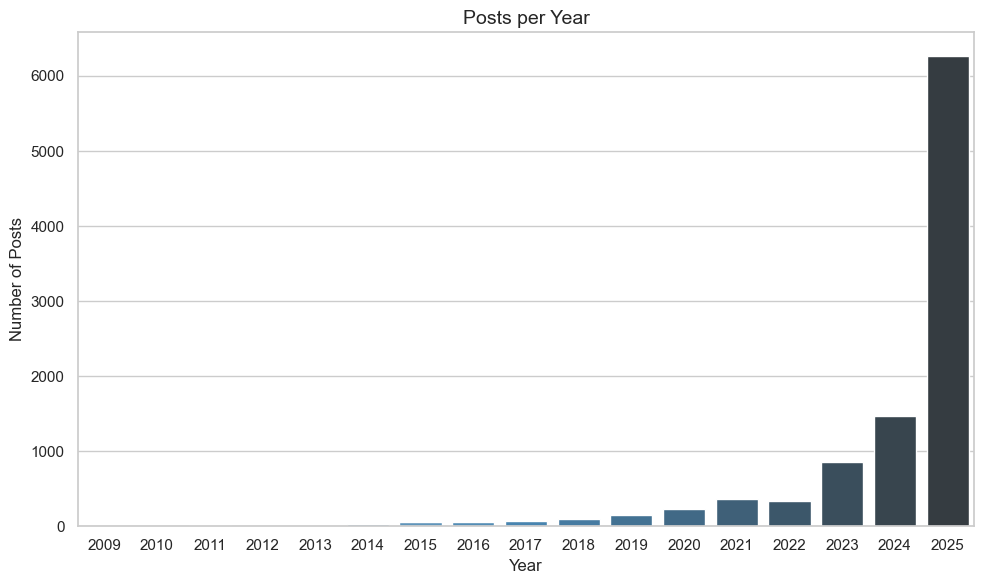

Saved posts per year chart to plots\posts_per_year.png


In [7]:
# Visualise posts per year
if df.empty:
    print('Dataset is empty; skipping posts per year chart.')
else:
    year_counts = df.groupby('year').size().reset_index(name='post_count')
    if year_counts.empty:
        print('No yearly counts available to plot.')
    else:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=year_counts, x='year', y='post_count', palette='Blues_d')
        plt.title('Posts per Year')
        plt.xlabel('Year')
        plt.ylabel('Number of Posts')
        plt.tight_layout()
        output_path = PLOTS_DIR / 'posts_per_year.png'
        plt.savefig(output_path, dpi=300)
        plt.show()
        print(f"Saved posts per year chart to {output_path}")

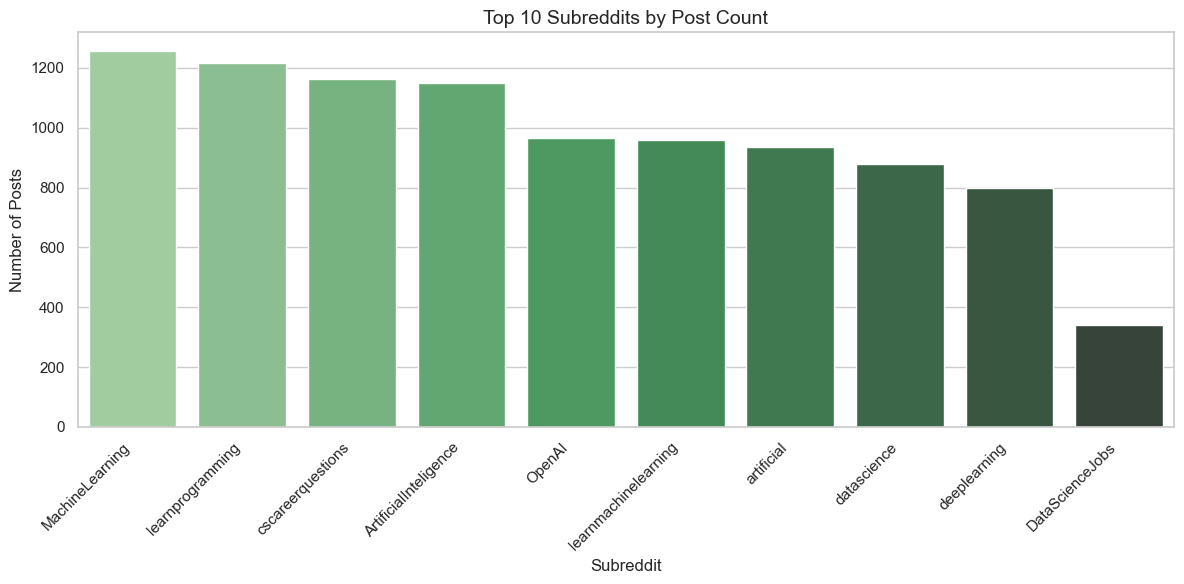

Saved subreddit chart to plots\top_subreddits.png


In [8]:
# Top 10 subreddits by post volume
if df.empty:
    print('Dataset is empty; skipping subreddit analysis.')
else:
    top_subreddits = df['subreddit'].value_counts().nlargest(10).reset_index()
    if top_subreddits.empty:
        print('No subreddit data available to plot.')
    else:
        top_subreddits.columns = ['subreddit', 'post_count']
        plt.figure(figsize=(12, 6))
        sns.barplot(data=top_subreddits, x='subreddit', y='post_count', palette='Greens_d')
        plt.title('Top 10 Subreddits by Post Count')
        plt.xlabel('Subreddit')
        plt.ylabel('Number of Posts')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        output_path = PLOTS_DIR / 'top_subreddits.png'
        plt.savefig(output_path, dpi=300)
        plt.show()
        print(f"Saved subreddit chart to {output_path}")

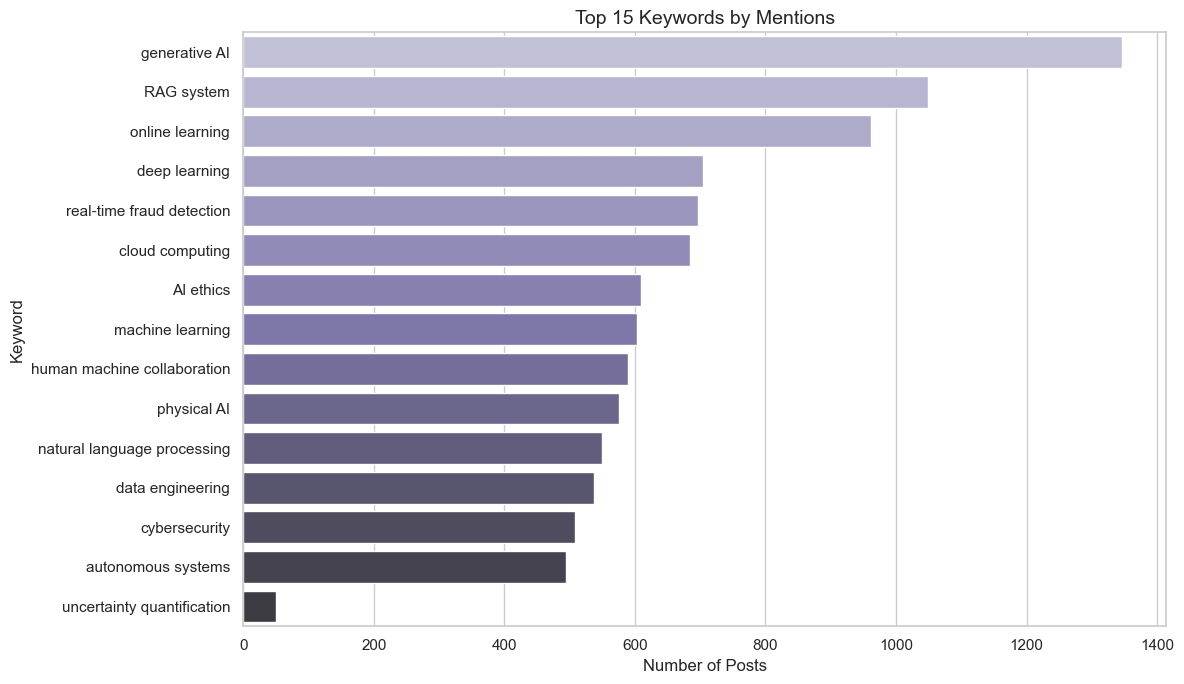

Saved keyword chart to plots\top_keywords.png


In [9]:
# Top 15 keywords (horizontal bar)
if df.empty:
    print('Dataset is empty; skipping keyword frequency plot.')
else:
    top_keywords = df['keyword'].value_counts().nlargest(15).reset_index()
    if top_keywords.empty:
        print('No keyword data available to visualise.')
    else:
        top_keywords.columns = ['keyword', 'post_count']
        plt.figure(figsize=(12, 7))
        sns.barplot(data=top_keywords, y='keyword', x='post_count', palette='Purples_d')
        plt.title('Top 15 Keywords by Mentions')
        plt.xlabel('Number of Posts')
        plt.ylabel('Keyword')
        plt.tight_layout()
        output_path = PLOTS_DIR / 'top_keywords.png'
        plt.savefig(output_path, dpi=300)
        plt.show()
        print(f"Saved keyword chart to {output_path}")

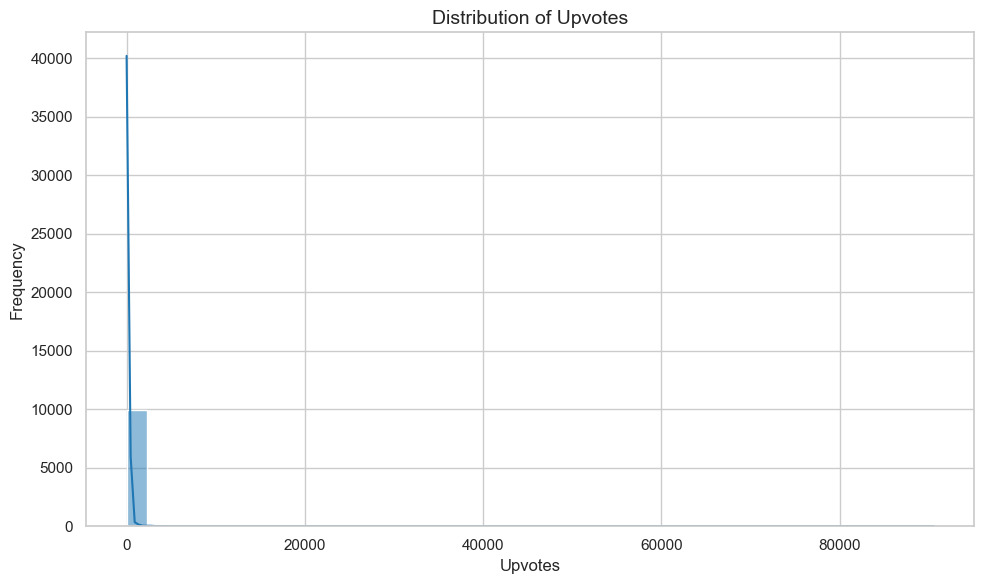

Saved upvotes histogram to plots\upvotes_distribution.png


In [32]:
# Upvotes distribution
if df.empty or 'upvotes' not in df.columns:
    print('Insufficient data to plot upvotes distribution.')
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['upvotes'], bins=40, kde=True, color='#1f77b4')
    plt.title('Distribution of Upvotes')
    plt.xlabel('Upvotes')
    plt.ylabel('Frequency')
    plt.tight_layout()
    output_path = PLOTS_DIR / 'upvotes_distribution.png'
    plt.savefig(output_path, dpi=300)
    plt.show()
    print(f"Saved upvotes histogram to {output_path}")

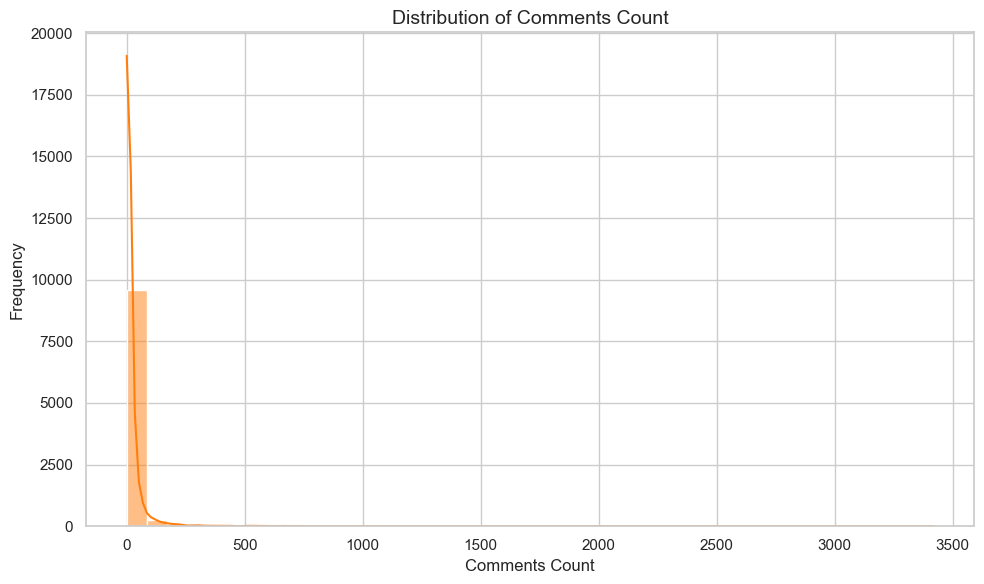

Saved comments histogram to plots\comments_distribution.png


In [12]:
# Comments count distribution
if df.empty or 'comments_count' not in df.columns:
    print('Insufficient data to plot comments distribution.')
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['comments_count'], bins=40, kde=True, color='#ff7f0e')
    plt.title('Distribution of Comments Count')
    plt.xlabel('Comments Count')
    plt.ylabel('Frequency')
    plt.tight_layout()
    output_path = PLOTS_DIR / 'comments_distribution.png'
    plt.savefig(output_path, dpi=300)
    plt.show()
    print(f"Saved comments histogram to {output_path}")

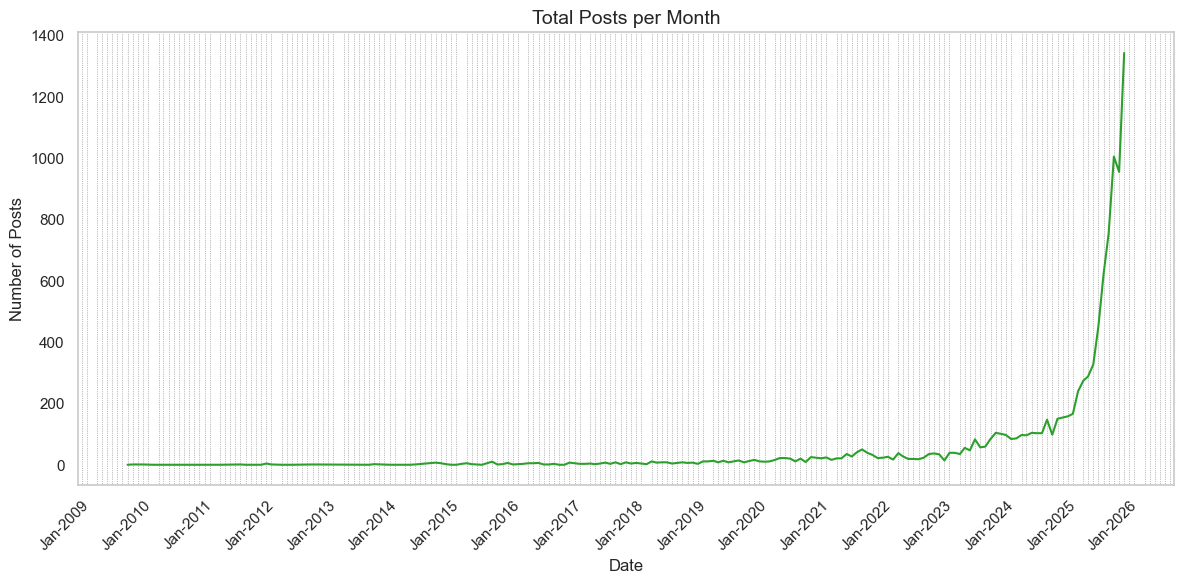

Saved monthly cadence chart to plots\posts_per_month.png


In [13]:
import matplotlib.dates as mdates # 1. ADD THIS IMPORT

if df.empty:
    print('Dataset is empty; skipping monthly cadence plot.')
else:
    monthly_counts = df.groupby('year_month').size().reset_index(name='post_count')
    if monthly_counts.empty:
        print('No monthly counts available to plot.')
    else:
        monthly_counts['month_start'] = pd.to_datetime(monthly_counts['year_month'] + '-01')
        monthly_counts = monthly_counts.sort_values('month_start')
        
        plt.figure(figsize=(12, 6))
        plt.plot(monthly_counts['month_start'], monthly_counts['post_count'], color='#2ca02c')
        plt.title('Total Posts per Month')
        plt.xlabel('Date')
        plt.ylabel('Number of Posts')
        
        # --- 2. GET THE PLOT'S AXIS ---
        ax = plt.gca() # Get the current plot axis

        # --- 3. SET MAJOR TICKS FOR JANUARY ---
        # Place a major tick at the start of every year (which is Jan)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        # Format the major tick label to be "Jan-YYYY"
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
        
        # --- 4. SET MINOR TICKS FOR OTHER MONTHS ---
        # Place a minor tick on every other month
        ax.xaxis.set_minor_locator(mdates.MonthLocator())
        
        # --- 5. ADD DOTTED GRIDLINES FOR MINOR TICKS ---
        # Turn on the grid
        ax.grid(True)
        # Add dotted gridlines ONLY for the minor ticks (Feb-Dec)
        ax.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')
        # Turn OFF gridlines for the major ticks (Jan) so they just have labels
        ax.grid(which='major', linestyle='none') 

        # Rotate the January labels so they fit
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        output_path = PLOTS_DIR / 'posts_per_month.png'
        plt.savefig(output_path, dpi=300)
        plt.show()
        print(f"Saved monthly cadence chart to {output_path}")

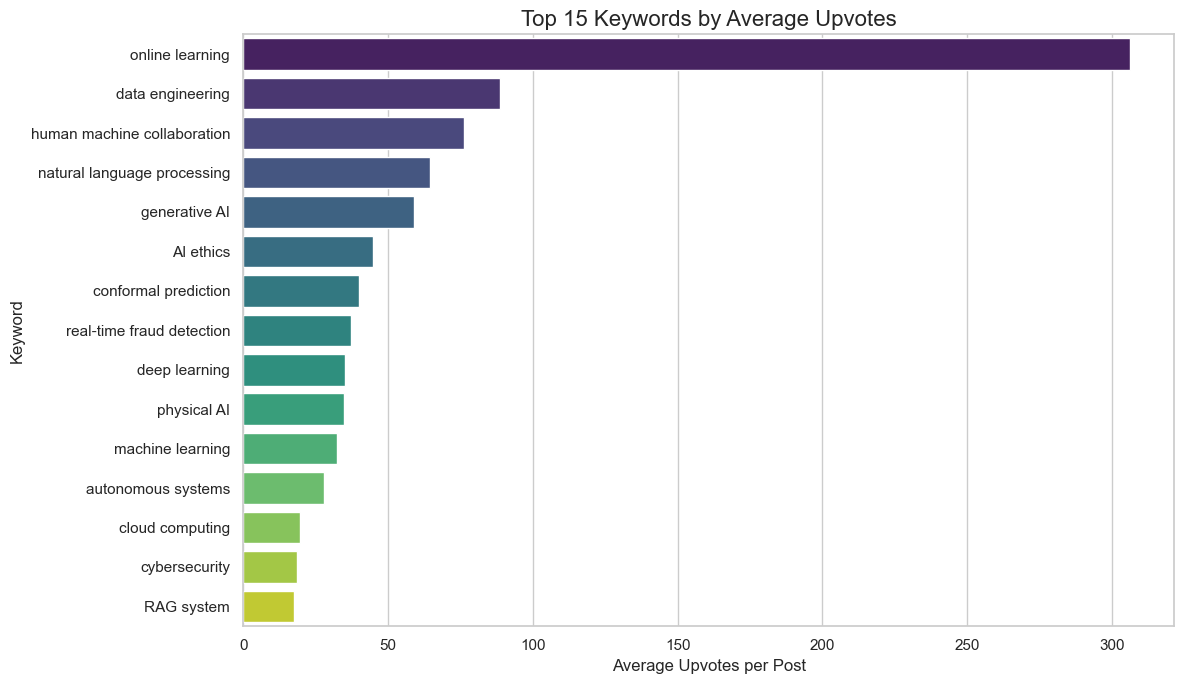

Plot saved to: plots\top_15_keywords_avg_upvotes.png


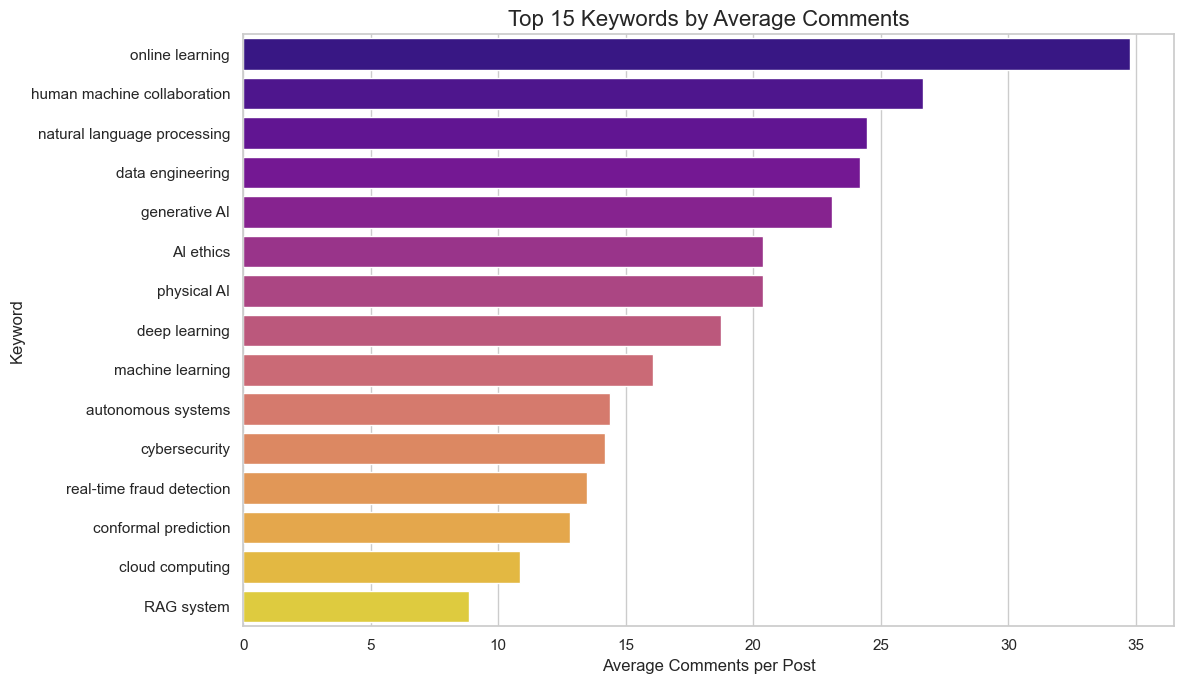

Plot saved to: plots\top_15_keywords_avg_comments.png


In [14]:
# --- NEW CELL ---
# Plot: Average Engagement (Upvotes/Comments) by Keyword

if df.empty or 'keyword' not in df.columns:
    print("DataFrame is empty or 'keyword' column is missing. Skipping engagement plot.")
else:
    # Group by keyword and calculate mean upvotes and comments
    keyword_engagement = df.groupby('keyword').agg(
        avg_upvotes=('upvotes', 'mean'),
        avg_comments=('comments_count', 'mean')
    ).reset_index()

    # --- Plot Top 15 by Avg Upvotes ---
    top_15_upvotes = keyword_engagement.nlargest(15, 'avg_upvotes')
    
    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_15_upvotes, y='keyword', x='avg_upvotes', palette='viridis')
    plt.title('Top 15 Keywords by Average Upvotes', fontsize=16)
    plt.xlabel('Average Upvotes per Post', fontsize=12)
    plt.ylabel('Keyword', fontsize=12)
    plt.tight_layout()
    
    output_path_upvotes = PLOTS_DIR / 'top_15_keywords_avg_upvotes.png'
    plt.savefig(output_path_upvotes, dpi=300)
    plt.show()
    print(f"Plot saved to: {output_path_upvotes}")

    # --- Plot Top 15 by Avg Comments ---
    top_15_comments = keyword_engagement.nlargest(15, 'avg_comments')
    
    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_15_comments, y='keyword', x='avg_comments', palette='plasma')
    plt.title('Top 15 Keywords by Average Comments', fontsize=16)
    plt.xlabel('Average Comments per Post', fontsize=12)
    plt.ylabel('Keyword', fontsize=12)
    plt.tight_layout()
    
    output_path_comments = PLOTS_DIR / 'top_15_keywords_avg_comments.png'
    plt.savefig(output_path_comments, dpi=300)
    plt.show()
    print(f"Plot saved to: {output_path_comments}")

# Stage 4 – Feature Engineering

We craft sentiment-aware and engagement-weighted monthly signals per skill, preparing the dataset for predictive modelling.


In [15]:
# Text preprocessing: merge title and body, clean, tokenise, and lemmatise
if df.empty:
    df['processed_text'] = []
    print('Dataset is empty; processed_text column initialised to empty.')
else:
    url_pattern = re.compile(r"http\\S+")
    punct_pattern = re.compile(r"[^a-zA-Z\\s]")

    def clean_and_lemmatise(row):
        text = f"{row.get('title', '')} {row.get('body', '')}"
        text = text.lower()
        text = url_pattern.sub(' ', text)
        text = punct_pattern.sub(' ', text)
        tokens = word_tokenize(text)
        filtered = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]
        return ' '.join(filtered)

    df['processed_text'] = df.apply(clean_and_lemmatise, axis=1)
    print('Processed text column created.')

Processed text column created.


In [16]:
# Sentiment extraction via VADER compound score
if 'processed_text' not in df.columns:
    df['processed_text'] = []
if df.empty:
    df['sentiment'] = []
    print('Dataset is empty; skipping sentiment computation.')
else:
    analyzer = SentimentIntensityAnalyzer()
    df['sentiment'] = df['processed_text'].apply(
        lambda text: analyzer.polarity_scores(text)['compound'] if isinstance(text, str) and text else 0.0
    )
    print('Sentiment scores computed.')

Sentiment scores computed.


In [17]:
# Buzz metric combines upvotes and comments as an engagement proxy
required_buzz_cols = {'upvotes', 'comments_count'}
if not required_buzz_cols.issubset(df.columns):
    df['buzz'] = []
    print('Required columns for buzz metric are missing; buzz set to empty.')
elif df.empty:
    df['buzz'] = []
    print('Dataset is empty; buzz metric initialised to empty.')
else:
    df['buzz'] = (
        df['upvotes'].astype(float) * df['comments_count'].astype(float)
    ).fillna(0.0)
    print('Buzz metric added.')

Buzz metric added.


In [18]:
# Monthly aggregation per keyword
monthly_features = pd.DataFrame()
if df.empty:
    print('Dataset is empty; monthly_features initialised as empty DataFrame.')
else:
    required_cols = {'keyword', 'year_month', 'processed_text', 'buzz', 'sentiment'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise KeyError(f"Cannot aggregate monthly features; missing columns: {sorted(missing_cols)}")

    monthly_features = (
        df.groupby(['keyword', 'year_month'], as_index=False)
          .agg(mention_count=('processed_text', 'size'),
               avg_buzz=('buzz', 'mean'),
               avg_sentiment=('sentiment', 'mean'))
    )

    monthly_features['month_start'] = pd.to_datetime(monthly_features['year_month'] + '-01')
    monthly_features = monthly_features.sort_values(['keyword', 'month_start']).reset_index(drop=True)

    monthly_features['prev_mentions'] = monthly_features.groupby('keyword')['mention_count'].shift(1)
    monthly_features['trend_growth'] = np.where(
        monthly_features['prev_mentions'] > 0,
        (monthly_features['mention_count'] - monthly_features['prev_mentions']) / monthly_features['prev_mentions'],
        0.0
    )
    monthly_features['trend_growth'] = monthly_features['trend_growth'].replace([np.inf, -np.inf], 0).fillna(0.0)

    monthly_features['year'] = monthly_features['month_start'].dt.year
    monthly_features['month'] = monthly_features['month_start'].dt.month

    monthly_features.drop(columns=['prev_mentions'], inplace=True)

    print('Monthly keyword aggregates generated.')

Monthly keyword aggregates generated.


In [19]:
monthly_features.head()

,keyword,year_month,mention_count,avg_buzz,avg_sentiment,month_start,trend_growth,year,month
0,AI ethics,2013-11,1,64.0,0.9718,2013-11-01,0.0,2013,11
1,AI ethics,2015-07,1,9.0,0.9485,2015-07-01,0.0,2015,7
2,AI ethics,2016-03,1,0.0,-0.9349,2016-03-01,0.0,2016,3
3,AI ethics,2017-02,1,6.0,0.9971,2017-02-01,0.0,2017,2
4,AI ethics,2017-03,1,3000.0,0.9062,2017-03-01,0.0,2017,3


In [20]:
# Feature scaling per keyword and weighted score construction
if monthly_features.empty:
    print('No monthly features available; skipping scaling and weighted score calculation.')
else:
    feature_columns = ['mention_count', 'avg_buzz', 'avg_sentiment', 'trend_growth']
    scaled_groups = []

    for keyword, group in monthly_features.groupby('keyword', sort=False):
        if group.empty:
            continue
        scaler = MinMaxScaler()
        scaled_array = scaler.fit_transform(group[feature_columns])
        scaled_df = pd.DataFrame(
            scaled_array,
            columns=[f'{col}_norm' for col in feature_columns],
            index=group.index
        )
        scaled_groups.append(pd.concat([group, scaled_df], axis=1))

    if not scaled_groups:
        raise ValueError('Scaling failed: no keyword groups produced scaled features.')

    monthly_features = pd.concat(scaled_groups).sort_values(['keyword', 'month_start']).reset_index(drop=True)

    monthly_features['weighted_score'] = (
        0.3 * monthly_features['mention_count_norm'] +
        0.4 * monthly_features['avg_buzz_norm'] +
        0.2 * monthly_features['avg_sentiment_norm'] +
        0.1 * monthly_features['trend_growth_norm']
    ) * 100
    monthly_features['weighted_score'] = monthly_features['weighted_score'].clip(lower=0, upper=100)

    monthly_features.to_csv(MONTHLY_FEATURES_PATH, index=False)
    monthly_features.to_csv('monthly_features.csv', index=False)

    df.drop(columns=[col for col in ['title', 'body', 'url', 'post_id'] if col in df.columns], inplace=True, errors='ignore')

    print(f"Monthly features saved to {MONTHLY_FEATURES_PATH.resolve()}")

Monthly features saved to C:\Users\gadda\Desktop\GHR\IDSE-pro\notebook_outputs\monthly_features.csv


# Stage 5 – Feature EDA

We examine engineered feature behaviour to prioritise skills and understand interactions ahead of modelling.


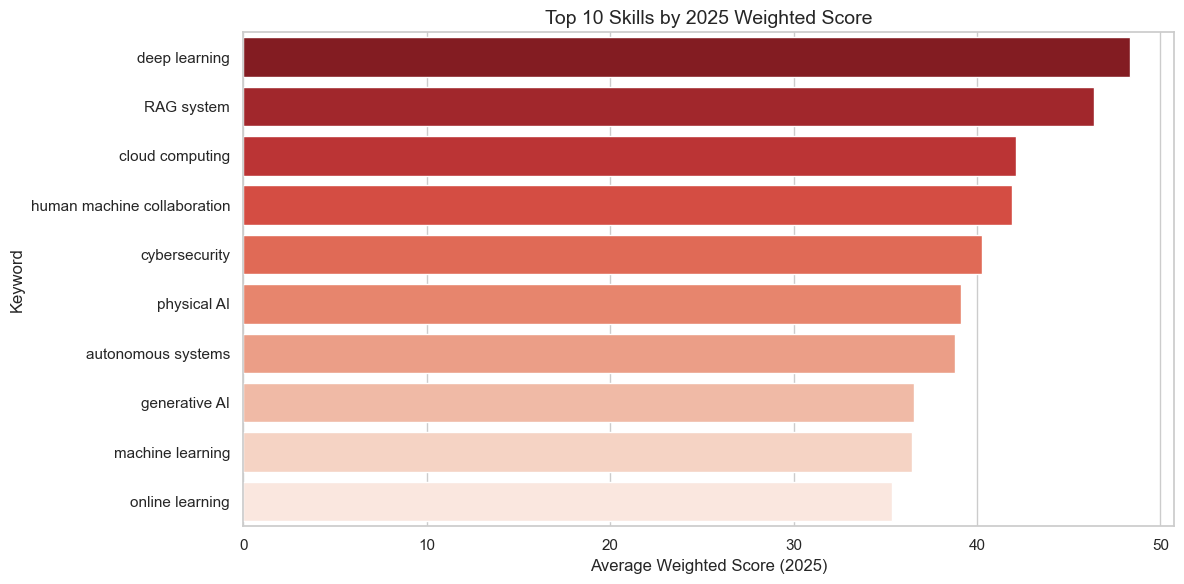

Saved top 2025 skills chart to plots\top_skills_2025.png


In [21]:
# Top 10 skills by average 2025 weighted score
if monthly_features.empty or 'weighted_score' not in monthly_features.columns:
    print('Monthly features unavailable; skipping 2025 weighted score analysis.')
else:
    scores_2025 = monthly_features[monthly_features['year'] == 2025]
    if scores_2025.empty:
        print('No 2025 data available for scoring.')
        top_scores_2025 = pd.Series(dtype=float)
    else:
        top_scores_2025 = (
            scores_2025.groupby('keyword')['weighted_score']
            .mean()
            .sort_values(ascending=False)
            .head(10)
        )
        plt.figure(figsize=(12, 6))
        sns.barplot(x=top_scores_2025.values, y=top_scores_2025.index, palette='Reds_r')
        plt.title('Top 10 Skills by 2025 Weighted Score')
        plt.xlabel('Average Weighted Score (2025)')
        plt.ylabel('Keyword')
        plt.tight_layout()
        output_path = PLOTS_DIR / 'top_skills_2025.png'
        plt.savefig(output_path, dpi=300)
        plt.show()
        print(f"Saved top 2025 skills chart to {output_path}")

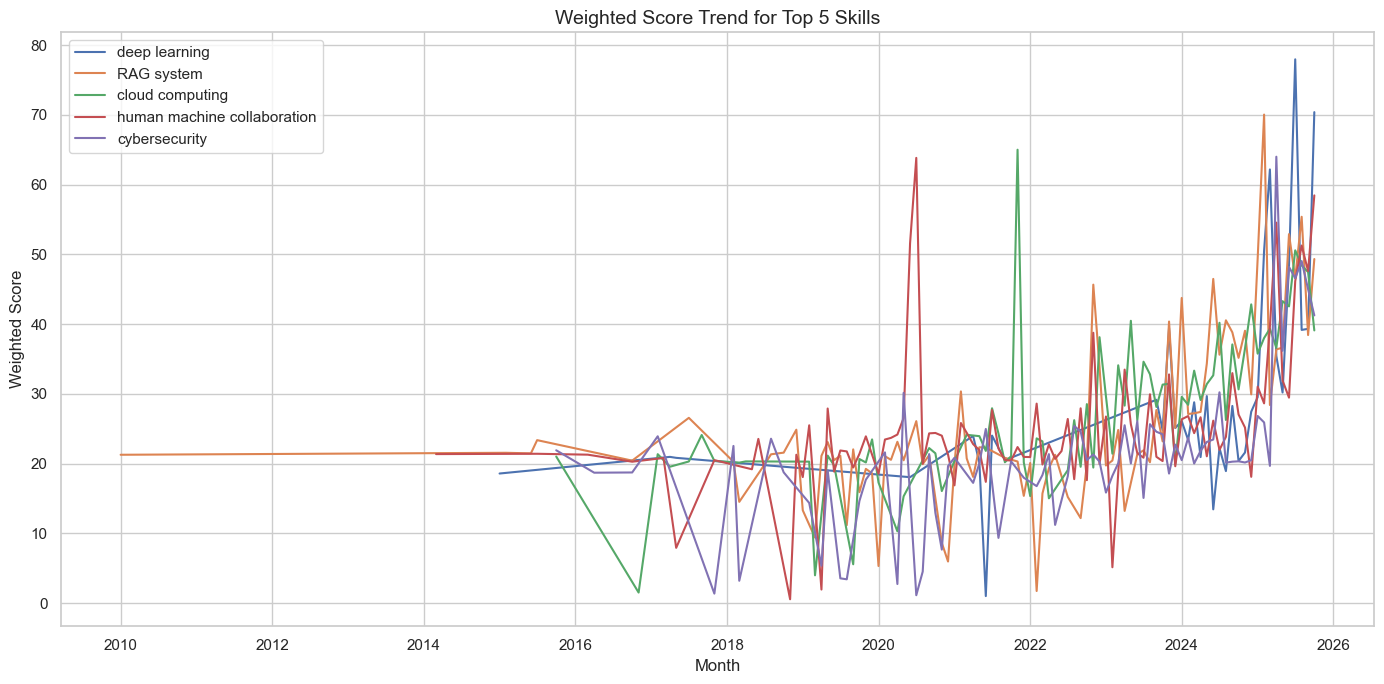

Saved trend chart to plots\top5_skill_trends.png


In [22]:
# Weighted score trend for top five skills (2018-2025)

if 'top_scores_2025' in locals() and not top_scores_2025.empty:

    top5_skills = top_scores_2025.index.tolist()[:5]

    trend_data = monthly_features[monthly_features['keyword'].isin(top5_skills)].sort_values('month_start')



    plt.figure(figsize=(14, 7))

    for skill in top5_skills:

        subset = trend_data[trend_data['keyword'] == skill]

        plt.plot(subset['month_start'], subset['weighted_score'], label=skill)

    plt.title('Weighted Score Trend for Top 5 Skills')

    plt.xlabel('Month')

    plt.ylabel('Weighted Score')

    plt.legend()

    plt.tight_layout()



    output_path = PLOTS_DIR / 'top5_skill_trends.png'

    plt.savefig(output_path, dpi=300)

    plt.show()



    print(f"Saved trend chart to {output_path}")

else:

    print('Insufficient top skill data to plot trends.')


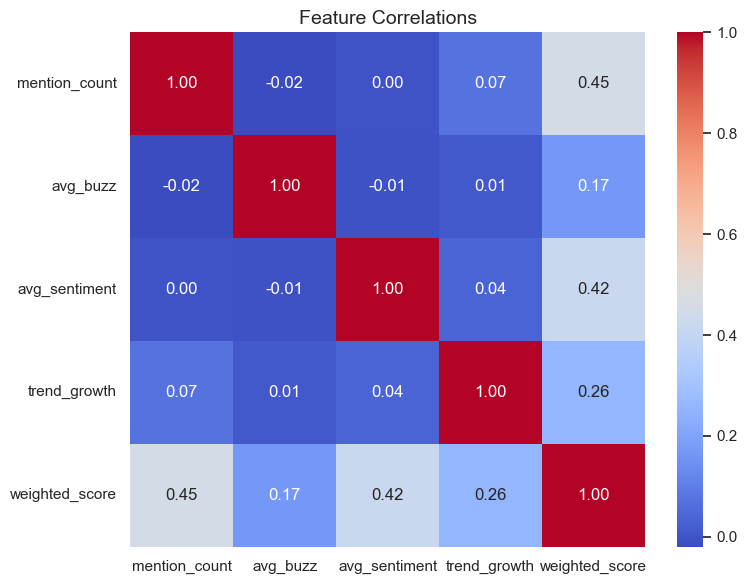

Saved correlation heatmap to plots\feature_correlations.png


In [23]:
# Feature correlation heatmap
if monthly_features.empty:
    print('Monthly features unavailable; skipping correlation heatmap.')
else:
    corr_features = [col for col in ['mention_count', 'avg_buzz', 'avg_sentiment', 'trend_growth', 'weighted_score'] if col in monthly_features.columns]
    if len(corr_features) < 2:
        print('Not enough features available to compute correlations.')
    else:
        corr_matrix = monthly_features[corr_features].corr()
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
        plt.title('Feature Correlations')
        plt.tight_layout()
        output_path = PLOTS_DIR / 'feature_correlations.png'
        plt.savefig(output_path, dpi=300)
        plt.show()
        print(f"Saved correlation heatmap to {output_path}")

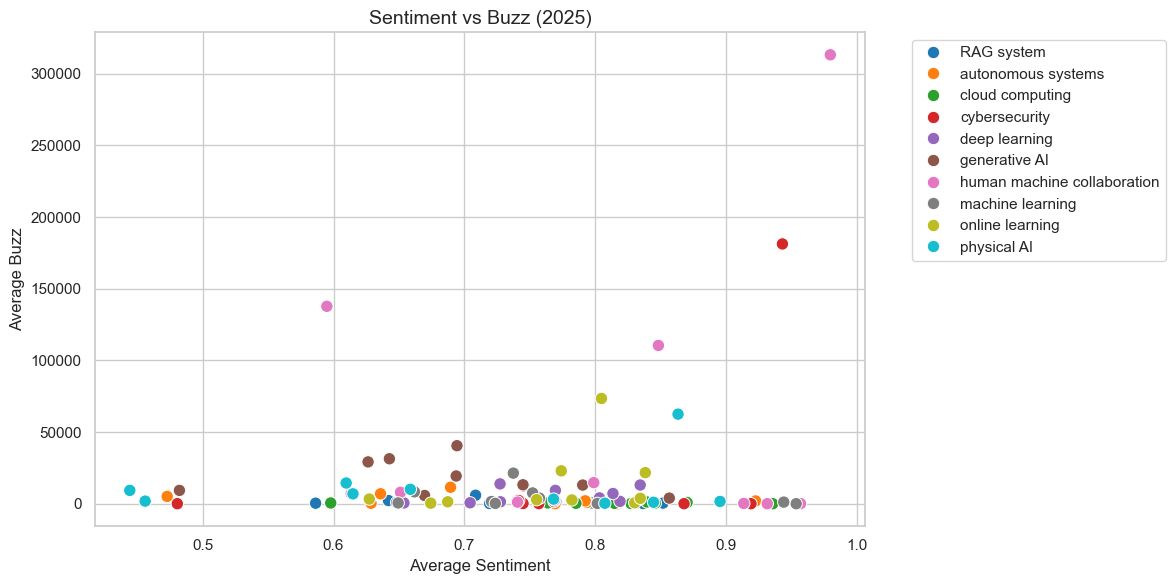

Saved sentiment vs buzz scatter to plots\sentiment_vs_buzz.png


In [24]:
# Sentiment vs buzz scatter for 2025 top keywords

if 'scores_2025' in locals() and not scores_2025.empty and 'top_scores_2025' in locals() and not top_scores_2025.empty:

    scatter_subset = scores_2025[scores_2025['keyword'].isin(top_scores_2025.index)]

    plt.figure(figsize=(12, 6))

    sns.scatterplot(data=scatter_subset, x='avg_sentiment', y='avg_buzz', hue='keyword', palette='tab10', s=80)

    plt.title('Sentiment vs Buzz (2025)')

    plt.xlabel('Average Sentiment')

    plt.ylabel('Average Buzz')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()



    output_path = PLOTS_DIR / 'sentiment_vs_buzz.png'

    plt.savefig(output_path, dpi=300, bbox_inches='tight')

    plt.show()



    print(f"Saved sentiment vs buzz scatter to {output_path}")

else:

    print('Insufficient data to plot sentiment vs buzz.')


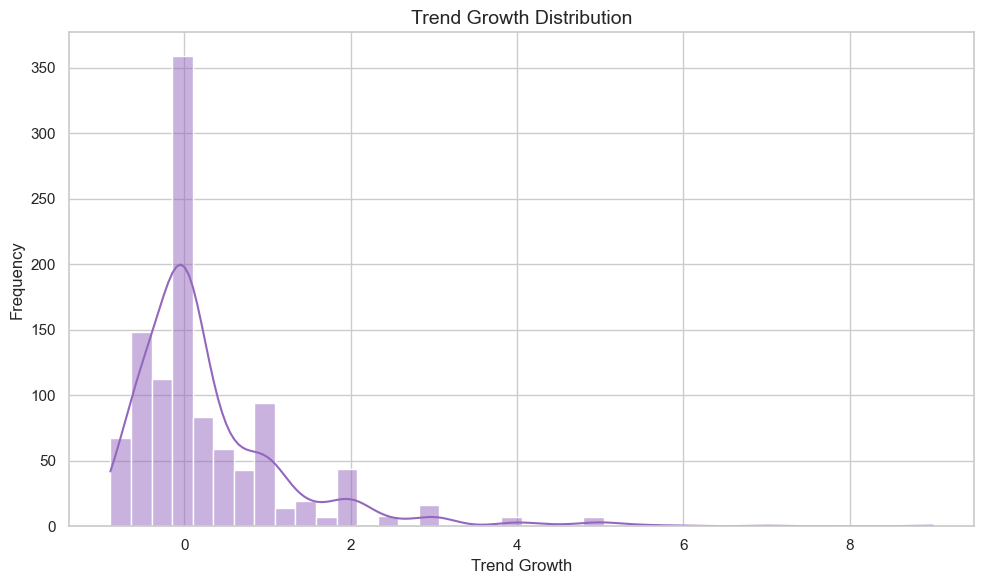

Saved trend growth distribution to plots\trend_growth_distribution.png


In [25]:
# Trend growth distribution
if monthly_features.empty or 'trend_growth' not in monthly_features.columns:
    print('Monthly features unavailable; skipping trend growth distribution.')
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(monthly_features['trend_growth'], bins=40, kde=True, color='#9467bd')
    plt.title('Trend Growth Distribution')
    plt.xlabel('Trend Growth')
    plt.ylabel('Frequency')
    plt.tight_layout()
    output_path = PLOTS_DIR / 'trend_growth_distribution.png'
    plt.savefig(output_path, dpi=300)
    plt.show()
    print(f"Saved trend growth distribution to {output_path}")

# Stage 6 – Modeling & Evaluation

We benchmark regression baselines, Prophet, and gradient boosting models to predict 2025 skill momentum and quantify performance.


In [26]:
# Prepare keyword-level time series with smoothing and storage containers
def build_keyword_frame(keyword, end_year=2025):
    subset = monthly_features[monthly_features['keyword'] == keyword][['month_start', 'weighted_score']].copy()
    if subset.empty:
        return pd.DataFrame()
    subset = subset.set_index('month_start').resample('MS').mean()
    subset['keyword'] = keyword
    subset['weighted_score'] = subset['weighted_score'].interpolate(limit_direction='both')
    subset['smoothed_score'] = subset['weighted_score'].rolling(window=3, min_periods=1).mean()
    subset = subset.dropna(subset=['smoothed_score'])
    return subset

FEATURE_COLS = ['month_index', 'month_sin', 'month_cos', 'lag_1', 'lag_3']
TARGET_COL = 'smoothed_score'

def enrich_with_temporal_features(frame):
    if frame.empty:
        return frame
    enriched = frame.copy()
    enriched['month'] = enriched.index.month
    enriched['month_index'] = np.arange(len(enriched))
    enriched['month_sin'] = np.sin(2 * np.pi * enriched['month'] / 12.0)
    enriched['month_cos'] = np.cos(2 * np.pi * enriched['month'] / 12.0)
    enriched['lag_1'] = enriched[TARGET_COL].shift(1)
    enriched['lag_3'] = enriched[TARGET_COL].shift(3)
    enriched = enriched.dropna(subset=['lag_1', 'lag_3']).copy()
    enriched['month_index'] = np.arange(len(enriched))
    enriched.drop(columns=['month'], inplace=True)
    return enriched

if monthly_features.empty:
    keywords = []
else:
    keywords = sorted(monthly_features['keyword'].unique())

metrics_records = []
prediction_frames = []

print(f"Prepared modeling frames for {len(keywords)} keywords.")

Prepared modeling frames for 16 keywords.


In [27]:
# Train baseline, Prophet, and XGBoost models per keyword; evaluate on 2025 months
for keyword in keywords:
    data_kw = build_keyword_frame(keyword, end_year=2025)
    if data_kw.empty:
        continue
    data_kw = enrich_with_temporal_features(data_kw)
    if data_kw.empty:
        continue

    train_mask = data_kw.index.year <= 2024
    test_mask = data_kw.index.year == 2025

    train_count = train_mask.sum()
    test_count = test_mask.sum()
    if train_count < 9 or test_count == 0:
        continue

    X_train = data_kw.loc[train_mask, FEATURE_COLS].values
    y_train = data_kw.loc[train_mask, TARGET_COL].values
    X_test = data_kw.loc[test_mask, FEATURE_COLS].values
    test_dates = data_kw.index[test_mask]
    actual_scores = data_kw.loc[test_mask, TARGET_COL].values
    actual_weighted_scores = data_kw.loc[test_mask, 'weighted_score'].values

    model_predictions = {}

    # Linear Regression
    try:
        lin_model = LinearRegression()
        lin_model.fit(X_train, y_train)
        model_predictions['LinearRegression'] = lin_model.predict(X_test)
    except Exception as exc:
        print(f"LinearRegression failed for {keyword}: {exc}")

    # Prophet
    try:
        prophet_train = pd.DataFrame({'ds': data_kw.index[train_mask], 'y': y_train})
        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        prophet_model.fit(prophet_train)
        future = prophet_model.make_future_dataframe(periods=len(test_dates), freq='MS', include_history=False)
        prophet_forecast = prophet_model.predict(future)
        model_predictions['Prophet'] = prophet_forecast['yhat'].values
    except Exception as exc:
        print(f"Prophet failed for {keyword}: {exc}")

    # XGBoost
    try:
        xgb_model = XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            objective='reg:squarederror',
            random_state=42
        )
        xgb_model.fit(X_train, y_train)
        model_predictions['XGBoostRegressor'] = xgb_model.predict(X_test)
    except Exception as exc:
        print(f"XGBoostRegressor failed for {keyword}: {exc}")

    # Persistence baseline (last observed value)
    try:
        last_observed = data_kw.loc[train_mask, TARGET_COL].iloc[-1]
        model_predictions['Persistence'] = np.full(test_count, last_observed)
    except Exception as exc:
        print(f"Persistence baseline failed for {keyword}: {exc}")

    for model_name, preds in model_predictions.items():
        if preds is None or len(preds) != len(actual_scores):
            continue
        preds = np.clip(preds, 0, 100)
        mae = mean_absolute_error(actual_scores, preds)
        rmse = np.sqrt(mean_squared_error(actual_scores, preds))
        r2 = r2_score(actual_scores, preds)

        metrics_records.append({
            'keyword': keyword,
            'model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

        prediction_frames.append(pd.DataFrame({
            'keyword': keyword,
            'model': model_name,
            'date': test_dates,
            'actual_score': actual_scores,
            'actual_weighted_score': actual_weighted_scores,
            'predicted_score': preds
        }))

metrics_df = pd.DataFrame(metrics_records)
predictions_2025_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()

if not metrics_df.empty:
    metrics_df.to_csv(MODEL_EVAL_PATH, index=False)
    metrics_df.to_csv('model_evaluation.csv', index=False)
    print(f"Model evaluation saved to {MODEL_EVAL_PATH.resolve()} with {len(metrics_df)} rows.")
else:
    print('No model metrics recorded. Check data sufficiency.')

10:19:08 - cmdstanpy - INFO - Chain [1] start processing
10:19:09 - cmdstanpy - INFO - Chain [1] done processing
10:19:11 - cmdstanpy - INFO - Chain [1] start processing
10:19:11 - cmdstanpy - INFO - Chain [1] done processing
10:19:12 - cmdstanpy - INFO - Chain [1] start processing
10:19:12 - cmdstanpy - INFO - Chain [1] done processing
10:19:12 - cmdstanpy - INFO - Chain [1] start processing
10:19:12 - cmdstanpy - INFO - Chain [1] done processing
10:19:13 - cmdstanpy - INFO - Chain [1] start processing
10:19:13 - cmdstanpy - INFO - Chain [1] done processing
10:19:14 - cmdstanpy - INFO - Chain [1] start processing
10:19:14 - cmdstanpy - INFO - Chain [1] done processing
10:19:14 - cmdstanpy - INFO - Chain [1] start processing
10:19:14 - cmdstanpy - INFO - Chain [1] done processing
10:19:15 - cmdstanpy - INFO - Chain [1] start processing
10:19:15 - cmdstanpy - INFO - Chain [1] done processing
10:19:15 - cmdstanpy - INFO - Chain [1] start processing
10:19:16 - cmdstanpy - INFO - Chain [1]

Model evaluation saved to C:\Users\gadda\Desktop\GHR\IDSE-pro\notebook_outputs\model_evaluation.csv with 64 rows.


In [28]:
# Identify the best-performing model per keyword (lowest MAE) and persist summary

if not metrics_df.empty:

    best_models = (

        metrics_df.sort_values('MAE')

        .groupby('keyword')

        .head(1)

        .reset_index(drop=True)

    )

    best_predictions_2025 = predictions_2025_df.merge(

        best_models[['keyword', 'model']],

        on=['keyword', 'model'],

        how='inner'

    )

    print(best_models.head())

else:

    best_models = pd.DataFrame()

    best_predictions_2025 = pd.DataFrame()

    print('No best models to report.')



print('Best models identified.')


                       keyword             model       MAE      RMSE        R2
0         conformal prediction       Persistence  1.932779  3.825790 -0.323202
1              online learning  LinearRegression  2.412601  3.462116  0.811919
2              cloud computing  LinearRegression  2.515799  2.997074  0.432927
3  natural language processing  LinearRegression  2.687976  3.118670  0.794340
4                generative AI  LinearRegression  3.179308  3.724612  0.654504
Best models identified.


# Stage 7 – Final Forecast & Deployment

We retrain the leading models through 2025, forecast 2026 trajectories, and package insights for consumption via Streamlit.


In [29]:
# Retrain best models on full 2018-2025 history and forecast 2026
from pandas.tseries.offsets import MonthBegin

forecast_frames = []
skill_forecast_records = []

def _iterative_forecast(model_predict, history_frame, future_dates):
    preds = []
    temp_history = history_frame.copy()
    next_month_index = temp_history['month_index'].iloc[-1] + 1
    for future_date in future_dates:
        month_sin = np.sin(2 * np.pi * future_date.month / 12.0)
        month_cos = np.cos(2 * np.pi * future_date.month / 12.0)
        lag_1 = temp_history[TARGET_COL].iloc[-1]
        lag_3 = temp_history[TARGET_COL].iloc[-3] if len(temp_history) >= 3 else lag_1
        features = np.array([[next_month_index, month_sin, month_cos, lag_1, lag_3]])
        pred = float(model_predict(features))
        pred = float(np.clip(pred, 0, 100))
        preds.append(pred)
        new_row = temp_history.iloc[[-1]].copy()
        new_row.index = [future_date]
        new_row[TARGET_COL] = pred
        new_row['weighted_score'] = pred
        new_row['month_index'] = next_month_index
        new_row['month_sin'] = month_sin
        new_row['month_cos'] = month_cos
        new_row['lag_1'] = lag_1
        new_row['lag_3'] = lag_3
        temp_history = pd.concat([temp_history, new_row])
        next_month_index += 1
    return np.array(preds, dtype=float)

if not keywords or best_models.empty:
    monthly_2026_forecast = pd.DataFrame()
    skill_forecast_df = pd.DataFrame()
    print('No best models available to generate forecasts.')
else:
    for _, row in best_models.iterrows():
        keyword = row['keyword']
        model_name = row['model']
        data_kw = build_keyword_frame(keyword, end_year=2025)
        data_kw = enrich_with_temporal_features(data_kw)
        if data_kw.empty:
            continue

        X_full = data_kw[FEATURE_COLS].values
        y_full = data_kw[TARGET_COL].values
        last_date = data_kw.index[-1]
        future_dates = pd.date_range(start=last_date + MonthBegin(1), periods=12, freq='MS')

        preds = None
        if model_name == 'LinearRegression':
            model = LinearRegression()
            model.fit(X_full, y_full)
            preds = _iterative_forecast(lambda feats: model.predict(feats)[0], data_kw, future_dates)
        elif model_name == 'Prophet':
            prophet_train_full = pd.DataFrame({'ds': data_kw.index, 'y': y_full})
            model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
            model.fit(prophet_train_full)
            future = model.make_future_dataframe(periods=len(future_dates), freq='MS', include_history=False)
            preds = model.predict(future)['yhat'].values
            preds = np.clip(preds, 0, 100)
        elif model_name == 'XGBoostRegressor':
            model = XGBRegressor(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
                objective='reg:squarederror',
                random_state=42
            )
            model.fit(X_full, y_full)
            preds = _iterative_forecast(lambda feats: model.predict(feats)[0], data_kw, future_dates)
        else:
            last_observed = data_kw[TARGET_COL].iloc[-1]
            preds = np.repeat(float(last_observed), len(future_dates))

        preds = np.clip(np.array(preds, dtype=float), 0, 100)

        forecast_df = pd.DataFrame({
            'keyword': keyword,
            'model': model_name,
            'date': future_dates,
            'predicted_score': preds
        })
        forecast_frames.append(forecast_df)
        skill_forecast_records.append({
            'keyword': keyword,
            'model': model_name,
            'score_2026': float(np.mean(preds))
        })

    if forecast_frames:
        monthly_2026_forecast = pd.concat(forecast_frames, ignore_index=True)
        skill_forecast_df = pd.DataFrame(skill_forecast_records).sort_values('score_2026', ascending=False)

        monthly_2026_forecast.to_csv(MONTHLY_FORECAST_PATH, index=False)
        monthly_2026_forecast.to_csv('monthly_2026_predictions.csv', index=False)
        skill_forecast_df.to_csv(SKILL_FORECAST_PATH, index=False)
        skill_forecast_df.to_csv('skill_forecast_2026.csv', index=False)

        print(f"Monthly 2026 forecast saved to {MONTHLY_FORECAST_PATH.resolve()}")
        print(f"Skill-level 2026 forecast saved to {SKILL_FORECAST_PATH.resolve()}")
    else:
        monthly_2026_forecast = pd.DataFrame()
        skill_forecast_df = pd.DataFrame()
        print('No forecasts generated; check data sufficiency.')

Monthly 2026 forecast saved to C:\Users\gadda\Desktop\GHR\IDSE-pro\notebook_outputs\monthly_2026_predictions.csv
Skill-level 2026 forecast saved to C:\Users\gadda\Desktop\GHR\IDSE-pro\notebook_outputs\skill_forecast_2026.csv


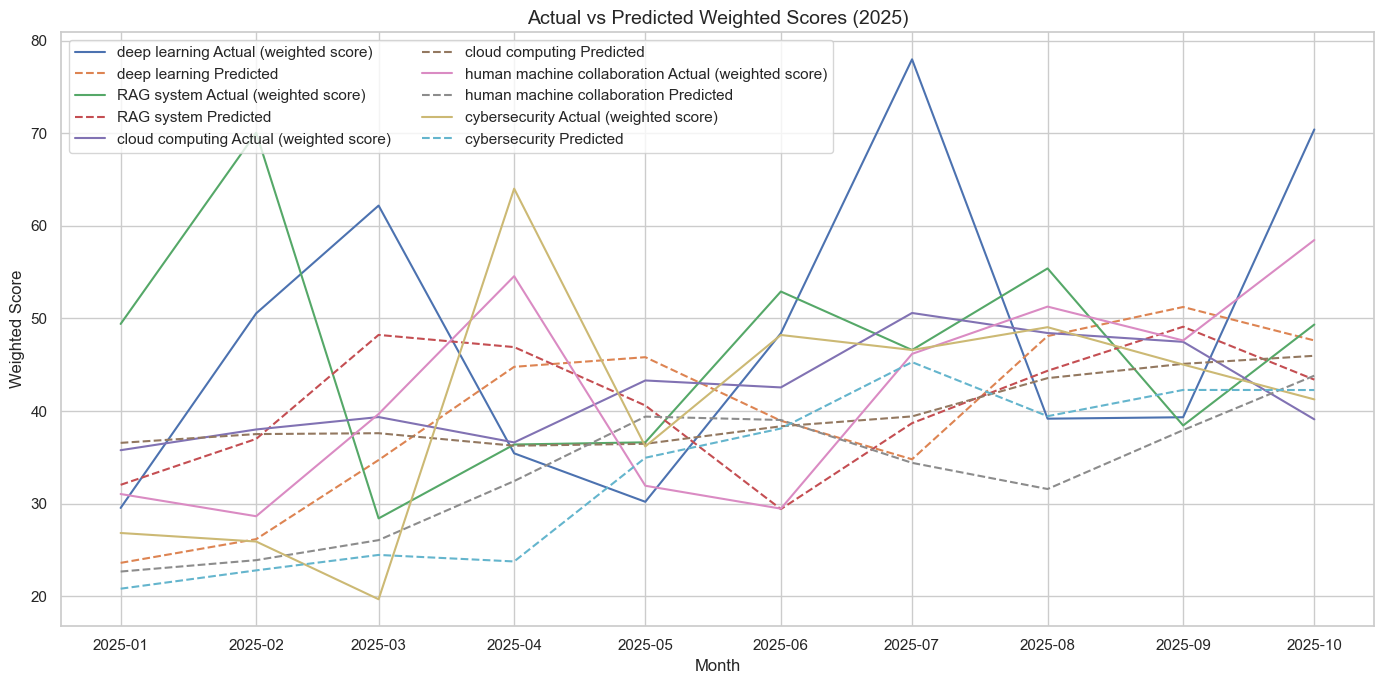

Saved actual vs predicted comparison to plots\actual_vs_predicted_2025.png


In [30]:
# Plot actual vs predicted 2025 monthly scores for top skills

if 'best_predictions_2025' in locals() and not best_predictions_2025.empty:

    if 'top_scores_2025' in locals() and not (isinstance(top_scores_2025, pd.Series) and top_scores_2025.empty):

        plot_skills = top_scores_2025.index.tolist()[:5]

    else:

        plot_skills = best_predictions_2025['keyword'].unique()[:5]

    actual_col = 'actual_weighted_score' if 'actual_weighted_score' in best_predictions_2025.columns else 'actual_score'
    actual_label = 'Actual (weighted score)' if actual_col == 'actual_weighted_score' else 'Actual'

    plt.figure(figsize=(14, 7))

    for skill in plot_skills:

        skill_df = best_predictions_2025[best_predictions_2025['keyword'] == skill].sort_values('date')

        if skill_df.empty:

            continue

        plt.plot(skill_df['date'], skill_df[actual_col], label=f'{skill} {actual_label}')

        plt.plot(skill_df['date'], skill_df['predicted_score'], linestyle='--', label=f'{skill} Predicted')

    plt.title('Actual vs Predicted Weighted Scores (2025)')

    plt.xlabel('Month')

    plt.ylabel('Weighted Score')

    plt.legend(ncol=2)

    plt.tight_layout()

    plot_path = PLOTS_DIR / 'actual_vs_predicted_2025.png'

    plt.savefig(plot_path, dpi=300)

    plt.show()

    print(f"Saved actual vs predicted comparison to {plot_path}")

else:

    print('No prediction data available to visualise actual vs predicted 2025.')

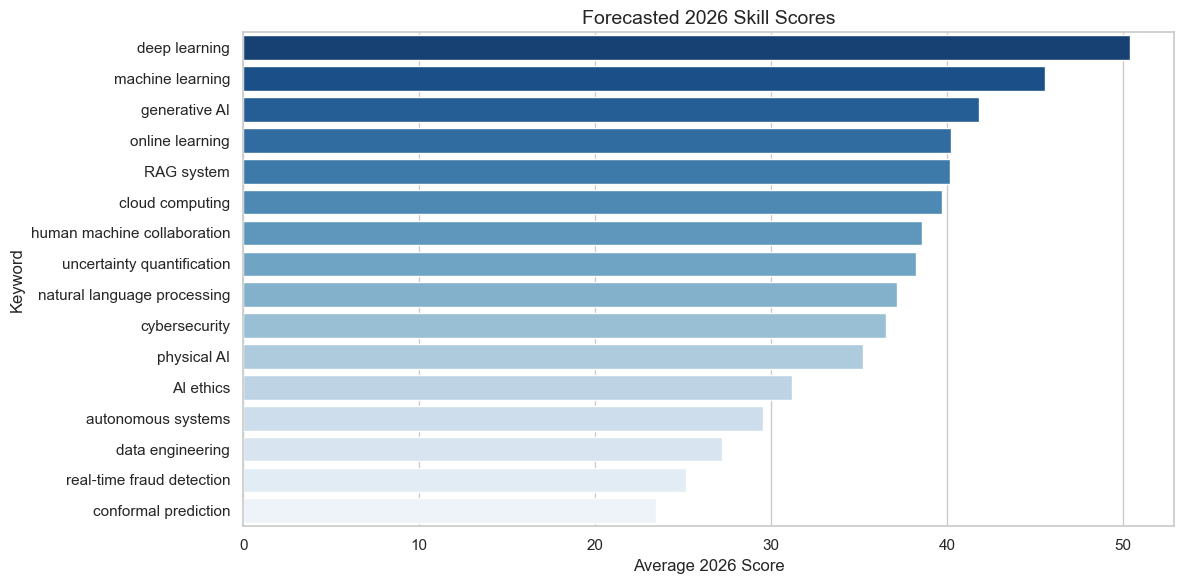

Saved 2026 forecast bar chart to plots\forecast_2026_bar.png

Monthly features preview:
     keyword year_month  mention_count  avg_buzz  avg_sentiment month_start  \
0  AI ethics    2013-11              1      64.0         0.9718  2013-11-01   
1  AI ethics    2015-07              1       9.0         0.9485  2015-07-01   
2  AI ethics    2016-03              1       0.0        -0.9349  2016-03-01   
3  AI ethics    2017-02              1       6.0         0.9971  2017-02-01   
4  AI ethics    2017-03              1    3000.0         0.9062  2017-03-01   

   trend_growth  year  month  mention_count_norm  avg_buzz_norm  \
0           0.0  2013     11                 0.0       0.000239   
1           0.0  2015      7                 0.0       0.000034   
2           0.0  2016      3                 0.0       0.000000   
3           0.0  2017      2                 0.0       0.000022   
4           0.0  2017      3                 0.0       0.011214   

   avg_sentiment_norm  trend_growt

,MAE,RMSE,R2
model,,,
LinearRegression,4.612,5.673,0.188
Persistence,10.113,11.869,-2.130
Prophet,12.491,14.273,-3.805
XGBoostRegressor,9.582,11.244,-2.427



Top 10 skills for 2026:
                        keyword             model  score_2026
12                deep learning  LinearRegression   50.367641
10             machine learning  LinearRegression   45.556581
4                 generative AI  LinearRegression   41.816498
1               online learning  LinearRegression   40.215667
13                   RAG system  LinearRegression   40.166740
2               cloud computing  LinearRegression   39.686320
11  human machine collaboration  LinearRegression   38.562934
15   uncertainty quantification  XGBoostRegressor   38.243818
3   natural language processing  LinearRegression   37.122701
9                 cybersecurity  LinearRegression   36.502671


In [31]:
# 2026 forecast visualisation and summary artefacts

if 'skill_forecast_df' in locals() and not skill_forecast_df.empty:

    plt.figure(figsize=(12, 6))

    sns.barplot(data=skill_forecast_df, x='score_2026', y='keyword', palette='Blues_r')

    plt.title('Forecasted 2026 Skill Scores')

    plt.xlabel('Average 2026 Score')

    plt.ylabel('Keyword')

    plt.tight_layout()



    plot_path = PLOTS_DIR / 'forecast_2026_bar.png'

    plt.savefig(plot_path, dpi=300)

    plt.show()



    print(f"Saved 2026 forecast bar chart to {plot_path}")

else:

    print('Skill forecast data not available for plotting.')



print('\nMonthly features preview:')

print(monthly_features.head())



if 'metrics_df' in locals() and not metrics_df.empty:

    print('\nAverage model performance:')

    display(metrics_df.groupby('model')[['MAE', 'RMSE', 'R2']].mean().round(3))

else:

    print('\nNo model metrics to summarise.')



if 'skill_forecast_df' in locals() and not skill_forecast_df.empty:

    print('\nTop 10 skills for 2026:')

    print(skill_forecast_df.head(10))

else:

    print('\nNo 2026 forecast available.')
